In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('Libraries loaded!')

Libraries loaded!


In [3]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f'Shape: {df.shape}')
print(f'\nAttrition Distribution:')
print(df['Attrition'].value_counts())
print(f'\nAttrition Rate: {df["Attrition"].value_counts(normalize=True)["Yes"]:.1%}')
df.head()

Shape: (1470, 35)

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


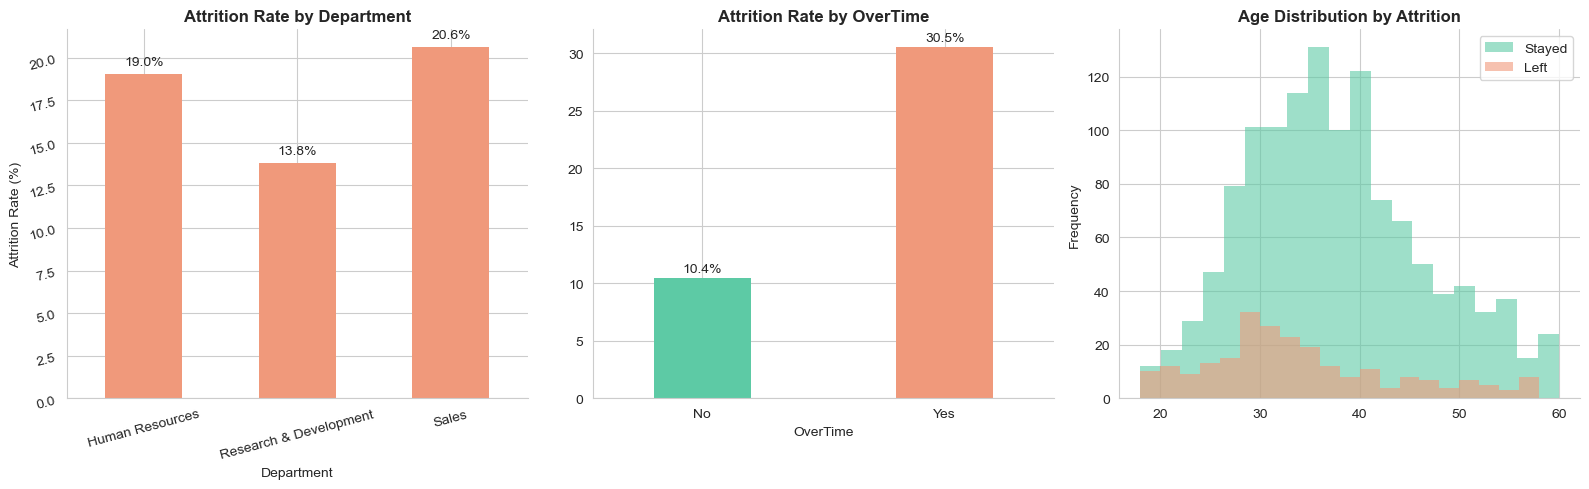

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Attrition by Department
dept = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean() * 100)
dept.plot(kind='bar', ax=axes[0], color='#F0997B', edgecolor='none', width=0.5)
axes[0].set_title('Attrition Rate by Department', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(rotation=15)
for i, v in enumerate(dept): axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=10)
sns.despine(ax=axes[0])

# Attrition by OverTime
ot = df.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean() * 100)
ot.plot(kind='bar', ax=axes[1], color=['#5DCAA5','#F0997B'], edgecolor='none', width=0.4)
axes[1].set_title('Attrition Rate by OverTime', fontweight='bold')
axes[1].tick_params(rotation=0)
for i, v in enumerate(ot): axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=10)
sns.despine(ax=axes[1])

# Age Distribution
df[df['Attrition']=='No']['Age'].plot(kind='hist', ax=axes[2], alpha=0.6, color='#5DCAA5', label='Stayed', bins=20, edgecolor='none')
df[df['Attrition']=='Yes']['Age'].plot(kind='hist', ax=axes[2], alpha=0.6, color='#F0997B', label='Left', bins=20, edgecolor='none')
axes[2].set_title('Age Distribution by Attrition', fontweight='bold')
axes[2].legend()
sns.despine(ax=axes[2])

plt.tight_layout()
plt.savefig('hr_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
df = df.drop(['EmployeeCount', 'EmployeeNumber',
              'Over18', 'StandardHours'], axis=1)

# Encode الـ target
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode الـ categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f'Final shape: {df.shape}')
print(f'Attrition balance: {df["Attrition"].value_counts().to_dict()}')
print('\\nReady for modeling!')

Final shape: (1470, 31)
Attrition balance: {0: 1233, 1: 237}
\nReady for modeling!


In [7]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = DecisionTreeClassifier(
    max_depth=5,           # مش عايزين الشجرة تبقى كبيرة أوي
    min_samples_split=20, # الحد الأدنى لتقسيم الـ node
    min_samples_leaf=10,  # الحد الأدنى في كل ورقة
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.1%}')
print('\\n--- Classification Report ---')
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Left']))

Accuracy: 84.0%
\n--- Classification Report ---
              precision    recall  f1-score   support

      Stayed       0.87      0.95      0.91       247
        Left       0.50      0.26      0.34        47

    accuracy                           0.84       294
   macro avg       0.69      0.60      0.62       294
weighted avg       0.81      0.84      0.82       294



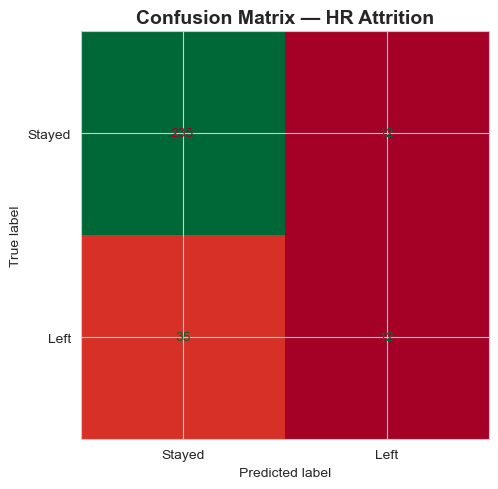

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Left'])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='RdYlGn', colorbar=False)
ax.set_title('Confusion Matrix — HR Attrition',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

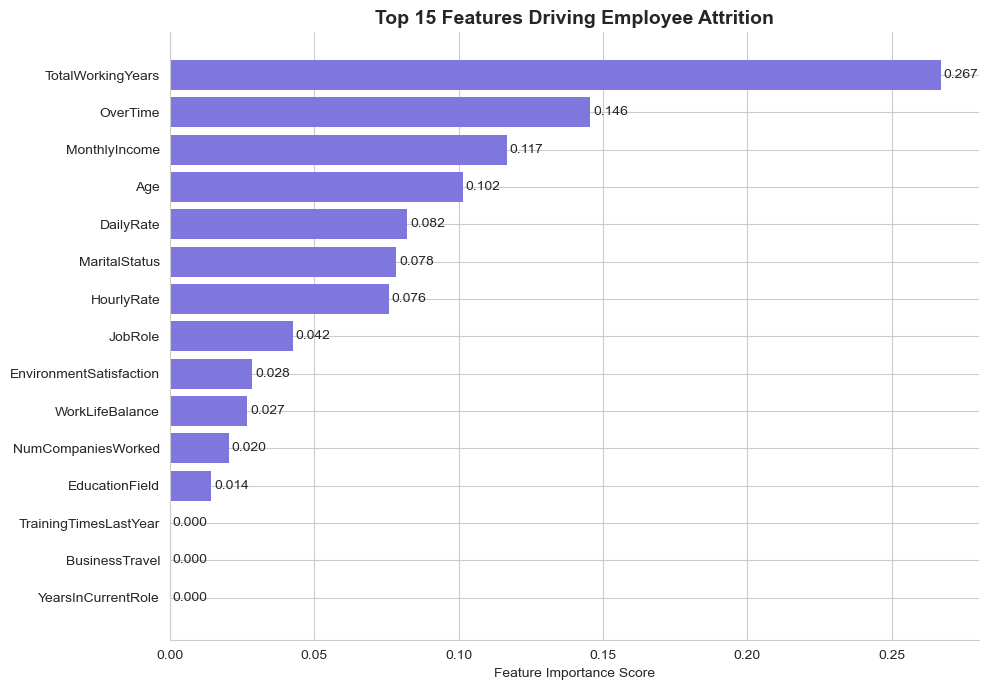

In [10]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance_df['feature'],
               importance_df['importance'],
               color='#7F77DD', edgecolor='none')

for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Top 15 Features Driving Employee Attrition',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 🌳 Key Insights & Business Recommendations

---

## 📊 Model Performance

| Metric | Value |
|--------|-------|
| Algorithm | Decision Tree Classifier |
| Accuracy | **84%** |
| Dataset | 1,470 employees |
| Attrition Rate | ~16% |

---

## 🔑 Top Factors Driving Attrition

| # | Factor | Insight |
|---|--------|---------|
| 1 | **Total Working Years** | Employees with fewer years of experience leave more — they're still exploring career options |
| 2 | **OverTime** | Employees working overtime have significantly higher attrition — burnout is a key driver |
| 3 | **Monthly Income** | Lower-paid employees are more likely to leave — compensation is a major retention factor |

---

## 💡 Business Recommendations

1. **Reduce Overtime** — Employees on heavy overtime are at high risk. Cap overtime hours or offer compensation
2. **Salary Review** — Conduct regular market benchmarking, especially for junior employees
3. **Early Career Support** — Employees in their first 3 years need mentorship and clear growth paths
4. **Monitor High-Risk Profiles** — Employees with low income + high overtime = highest attrition risk

---

*Analysis by Rania Mofeed | Tools: Python · Scikit-learn · Pandas · Matplotlib*